<div style="
  background: linear-gradient(135deg, #ff9a9e, #fad0c4, #fbc2eb);
  padding: 28px;
  border-radius: 24px;
  text-align: center;
  color: #3a2c4a;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🌈 DaneshChat AI Adventure 🚀
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build Smart Models for lost & Message Loss Detection
  </h2>

  <p style="font-size: 18px;">
    Welcome, young AI engineer! Today you will train machines to understand messages better.
  </p>

</div>

### Imports

In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

### Load the dataset

In [279]:
# Read the CSV file named "daneshchat_logs.csv"
DATA_DIR = "Data/"
DANESHCHAT_CSV_PATH = f"{DATA_DIR}daneshchat_logs.csv"

# Store it in a variable named df
df = pd.read_csv(DANESHCHAT_CSV_PATH)

# Show the first 5 rows
df.head()

,message_size_kb,transfer_steps,connection_quality,has_urgent_keyword,has_link,is_spam,is_lost
0,49.73,10,0.954,0,0,0,0
1,60.27,4,0.369,0,0,0,1
2,77.18,17,0.025,0,0,0,1
3,21.13,8,0.334,1,0,1,1
4,39.09,2,0.664,0,0,0,0


### Quick data check

In [280]:
END = "\n" + "-" * 40 + "\n"
print("=" * 40)
print("\tQuick Look at the Data")
print("=" * 40)
# Print the shape of the dataset
print(f"Shape: {df.shape}", end=END)
# Print the column names
print(f"Columns: {df.columns.to_list()}", end=END)
# Check missing values
print(f"Misssing Values:\n{df.isnull().sum()}", end=END)
# Show basic statistics using describe()
print(f"Basic Statistics:")
print(df.describe())
print("=" * 40)

	Quick Look at the Data
Shape: (6000, 7)
----------------------------------------
Columns: ['message_size_kb', 'transfer_steps', 'connection_quality', 'has_urgent_keyword', 'has_link', 'is_spam', 'is_lost']
----------------------------------------
Misssing Values:
message_size_kb       0
transfer_steps        0
connection_quality    0
has_urgent_keyword    0
has_link              0
is_spam               0
is_lost               0
dtype: int64
----------------------------------------
Basic Statistics:
       message_size_kb  transfer_steps  connection_quality  \
count      6000.000000     6000.000000         6000.000000   
mean         65.794645        8.684667            0.595544   
std         121.959485        6.041494            0.266757   
min           1.000000        1.000000            0.000000   
25%          23.342500        4.000000            0.399750   
50%          40.830000        7.000000            0.644000   
75%          67.992500       12.000000            0.811250   

### Clean the dataset

In [281]:
# Remove duplicated rows
df = df.drop_duplicates()
# Convert columns to numeric if needed
numeric_cols = ['message_size_kb', 'transfer_steps', 'connection_quality', 'has_urgent_keyword', 'has_link', 'is_spam', 'is_lost']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Remove rows with missing values
df = df.dropna()
# Keep only valid connection_quality values between 0 and 1
df = df[(0 <= df["connection_quality"]) & (df['connection_quality'] <= 1)]
# Keep only positive message_size_kb and transfer_steps
df = df[(df["message_size_kb"] > 0) & (df["transfer_steps"] > 0)]

print(f"Cleanded Dataset shape: f{df.shape}")
df.head()

Cleanded Dataset shape: f(6000, 7)


,message_size_kb,transfer_steps,connection_quality,has_urgent_keyword,has_link,is_spam,is_lost
0,49.73,10,0.954,0,0,0,0
1,60.27,4,0.369,0,0,0,1
2,77.18,17,0.025,0,0,0,1
3,21.13,8,0.334,1,0,1,1
4,39.09,2,0.664,0,0,0,0


<div style="
  background: linear-gradient(135deg, #74c69d, #48cae4);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #2d6a4f;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #081c15;
">

  <h1 style="
    color: #081c15;
    background-color: rgba(255, 255, 255, 0.65);
    padding: 12px 16px;
    border-radius: 14px;
    margin-top: 0;
  ">
    🌳 Part A: Build a Decision Tree from Scratch
  </h1>

  <p style="
    font-size: 17px;
    line-height: 1.7;
    color: #133f30;
    font-weight: 500;
  ">
    In this part, you will build your own Decision Tree classifier.
    You may use Python, NumPy, and Pandas, but not a ready-made Decision Tree model.
  </p>

  <pre style="
    background-color: #0f4331;
    color: #d8f3dc;
    padding: 16px;
    border-radius: 14px;
    border: 3px solid #95d5b2;
    font-size: 15px;
    line-height: 1.6;
    overflow-x: auto;
  ">Is connection_quality <= 0.45?

├── Yes: maybe lost

└── No: maybe delivered</pre>

</div>

### Create a Node class

In [282]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature # Store the feature name used for splitting
        self.threshold = threshold # Store the threshold value
        self.left = left # Store the left child
        self.right = right # Store the right child
        self.value = value # Store the final prediction value for leaf nodes

    def is_leaf(self):
        """Return True if this node is a leaf""" 
        return self.value is not None # True if a node a prediction value

### Decision Tree Classifier from Scratch

In [283]:
class DecisionTreeClassifierScratch:
    def __init__(self, max_depth=5, min_samples_split=20, min_samples_leaf=10, binary_classifiction = True):
        self.max_depth = max_depth # Store max_depth
        self.min_samples_split = min_samples_split # Store min_samples_split
        self.min_samples_leaf = min_samples_leaf # Store min_samples_leaf
        self.root = None # Create a variable named root and set it to None
        self.binary_classifiction = binary_classifiction

    def entropy(self, y):
        """Calculate entropy using class probabilities"""
        if len(y) == 0:
            return 0.0
        
        values, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities + 1e-9))   # Add a small value to avoid log(0)

    def information_gain(self, y, y_left, y_right):
        """Info Gain = Parent Entropy - Weightened Children Entropy"""
        if len(y) == 0:
            return 0.0        
    
        # Calculate parent entropy
        parent_entropy = self.entropy(y)
        # Calculate weighted child entropy
        children_entropy = len(y_left) * self.entropy(y_left) + \
                           len(y_right) * self.entropy(y_right)
        children_entropy = children_entropy / len(y)
        # Return information gain
        return parent_entropy - children_entropy

    def majority_class(self, y):
        """Return the most common class in y"""
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def find_best_split(self, X : pd.DataFrame, y):
        """Find the best feature to split by using information gain"""
        best_gain = -np.inf
        best_feature = None
        best_threshold = None
        # Try each feature
        for feature in X.columns:
            col_values = X[feature].values
            unique_values = np.sort(np.unique(col_values))
            if len(unique_values) <= 1:
                continue
            
            # Try possible thresholds for each feature
            for threshold in unique_values:
                # Split y into left and right groups
                y_left = y[col_values <= threshold]
                y_right = y[col_values > threshold]

                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                # Calculate information gain
                gain = self.information_gain(y, y_left, y_right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        # Return best feature and best threshold
        return best_feature, best_threshold

    def build_tree(self, X : pd.DataFrame, y, depth=0):
        """Recursively build the decision tree and return the root Node."""
        node_value = self.majority_class(y) if self.binary_classifiction else np.mean(y == 1)

        # Check stopping conditions
        if depth >= self.max_depth or \
           len(y) < self.min_samples_split or \
           len(np.unique(y)) == 1:              # Pure node

            return Node(value=node_value)
        
        # Find the best split
        best_feature, best_threshold = self.find_best_split(X, y)
        if best_feature is None:
            return Node(value=node_value)
        
        # Build left and right child nodes recursively
        mask_left = X[best_feature].values <= best_threshold
        mask_right = X[best_feature].values > best_threshold

        X_left, y_left = X[mask_left], y[mask_left]
        X_right, y_right = X[mask_right], y[mask_right]

        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)
        
        # Return a Node
        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """Build the tree and store it in self.root"""
        self.root = self.build_tree(X, y)

    def predict_one(self, row):
        """Traverse the tree for a single sample and return the predicted label."""
        # Start from the root
        node = self.root
        # Move left or right until reaching a leaf
        while not node.is_leaf():
            node = node.left if row[node.feature] <= node.threshold else node.right
        # Return the leaf value
        return node.value
        
    def predict(self, X : pd.DataFrame, threshold = 0.5):
        """Predict each row in X"""
        probs = np.array([self.predict_one(row) for _, row in X.iterrows()])
        return (probs >= threshold).astype(int)

### Prepare data for spam prediction

In [284]:
# Set y_spam to df["is_spam"]
y_spam = df["is_spam"]
# Set X_spam by dropping both "is_spam" and "is_lost"
X_spam = df.drop(columns=["is_spam", "is_lost"])
# Split X_spam and y_spam into train and validation sets
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, stratify=y_spam
)

print("=" * 40)
print(f"Train Size: {X_train_spam.shape}\t| Test Size: {X_test_spam.shape}")
print("=" * 40)

Train Size: (4800, 5)	| Test Size: (1200, 5)


### Train your scratch Decision Tree for spam

In [285]:
# Create a DecisionTreeClassifierScratch object
descision_tree_spam_scratch_binary = DecisionTreeClassifierScratch(binary_classifiction=True)
# Fit it on X_train_spam and y_train_spam
descision_tree_spam_scratch_binary.fit(X_train_spam, y_train_spam)
# Predict on X_val_spam
y_pred_spam_scratch_binary = descision_tree_spam_scratch_binary.predict(X_test_spam)

In [286]:
descision_tree_spam_scratch_ratio = DecisionTreeClassifierScratch(binary_classifiction=False)
descision_tree_spam_scratch_ratio.fit(X_train_spam, y_train_spam)

best_metric = -np.inf
for spam_detect_threshold in np.linspace(0, 1, 20):
    temp_predict = descision_tree_spam_scratch_ratio.predict(X_test_spam, spam_detect_threshold)
    temp_f1 = f1_score(y_test_spam, temp_predict, zero_division=0)
    temp_precision = precision_score(y_test_spam, temp_predict, zero_division=0)
    temp_metric = (2 * temp_f1 * temp_precision) / (temp_f1 + temp_precision)
    if temp_metric > best_metric:
        y_pred_spam_scratch_ratio = temp_predict.copy()
        best_metric = temp_metric
        best_threshold = spam_detect_threshold

print(f"Best Threshold to have maximum F1 Score with focus on Precision: {best_threshold:.4f}")

Best Threshold to have maximum F1 Score with focus on Precision: 0.4211


### Create an evaluation function

Model: Scratch Binary Decision Tree on Spam detection
Accuracy:	0.6933
----------------------------------------
Precision:	0.7891
----------------------------------------
Recall:		0.3915
----------------------------------------
F1 Score:	0.5233


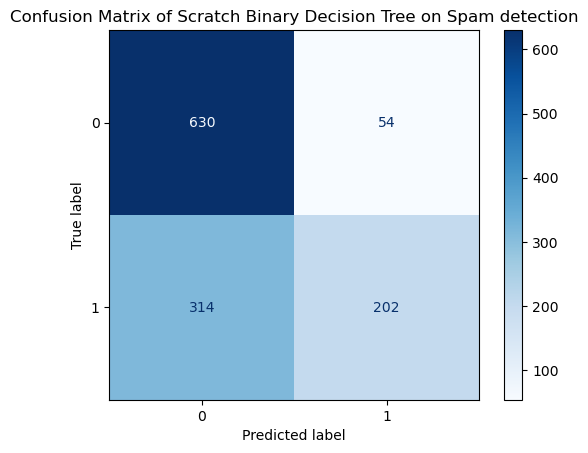

Model: Scratch Binary Ratio Tree on Spam detection
Accuracy:	0.6950
----------------------------------------
Precision:	0.6984
----------------------------------------
Recall:		0.5116
----------------------------------------
F1 Score:	0.5906


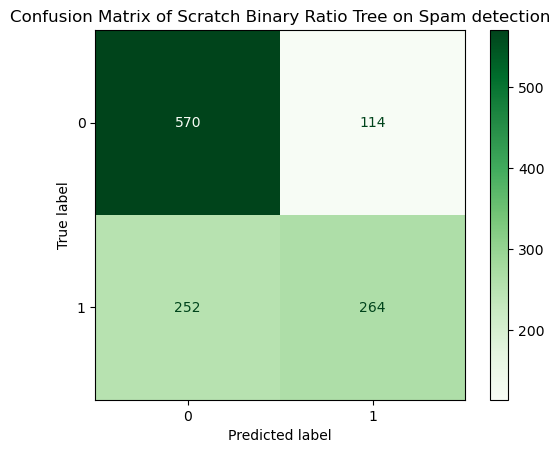

In [313]:
def evaluate_model(y_true, y_pred, model_name, color = None):
    """Print Accuracy, Precision, Recall, F1 and plot Confusion Matrix."""
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    # Calculate precision
    precision = precision_score(y_true, y_pred, zero_division=0)
    # Calculate recall
    recall = recall_score(y_true, y_pred, zero_division=0)
    # Calculate F1-score
    f1 = f1_score(y_true, y_pred, zero_division=0)
    # Print the results in a nice format
    print("=" * 40)
    print(f"Model: {model_name}")
    print("=" * 40)
    print(f"Accuracy:\t{accuracy:.4f}", end=END)
    print(f"Precision:\t{precision:.4f}", end=END)
    print(f"Recall:\t\t{recall:.4f}", end=END)
    print(f"F1 Score:\t{f1:.4f}")
    print("=" * 40)

    confusion_mat = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_mat)
    disp.plot(cmap=color)
    plt.title(f"Confusion Matrix of {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    }

scratch_binary_spam_res = evaluate_model(y_test_spam, y_pred_spam_scratch_binary, "Scratch Binary Decision Tree on Spam detection", "Blues")
scratch_ratio_spam_res = evaluate_model(y_test_spam, y_pred_spam_scratch_ratio, "Scratch Binary Ratio Tree on Spam detection", "Greens")

---
### Lost prediction

In [314]:
y_lost = df["is_spam"]
X_lost = df.drop(columns=["is_spam", "is_lost"])
X_train_lost, X_test_lost, y_train_lost, y_test_lost = train_test_split(
    X_lost, y_lost, test_size=0.2, stratify=y_lost
)

print("=" * 40)
print(f"Train Size: {X_train_lost.shape}\t| Test Size: {X_test_lost.shape}")
print("=" * 40)

Train Size: (4800, 5)	| Test Size: (1200, 5)


In [315]:
descision_tree_lost_scratch_binary = DecisionTreeClassifierScratch(binary_classifiction=True)
descision_tree_lost_scratch_binary.fit(X_train_lost, y_train_lost)
y_pred_lost_scratch_binary = descision_tree_lost_scratch_binary.predict(X_test_lost)

In [316]:
descision_tree_lost_scratch_ratio = DecisionTreeClassifierScratch(binary_classifiction=False)
descision_tree_lost_scratch_ratio.fit(X_train_lost, y_train_lost)

best_metric = -np.inf
for lost_detect_threshold in np.linspace(0, 1, 20):
    temp_predict = descision_tree_lost_scratch_ratio.predict(X_test_lost, lost_detect_threshold)
    temp_f1 = f1_score(y_test_lost, temp_predict, zero_division=0)
    temp_precision = precision_score(y_test_lost, temp_predict, zero_division=0)
    temp_metric = (2 * temp_f1 * temp_precision) / (temp_f1 + temp_precision)
    if temp_metric > best_metric:
        y_pred_lost_scratch_ratio = temp_predict.copy()
        best_metric = temp_metric
        best_threshold = lost_detect_threshold

print(f"Best Threshold to have maximum F1 Score with focus on Precision: {best_threshold:.4f}")

Best Threshold to have maximum F1 Score with focus on Precision: 0.4211


Model: Scratch Binary Decision Tree on Lost detection
Accuracy:	0.6950
----------------------------------------
Precision:	0.7907
----------------------------------------
Recall:		0.3953
----------------------------------------
F1 Score:	0.5271


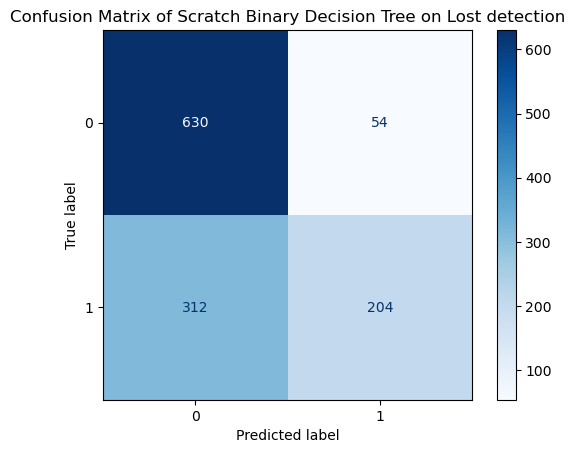

Model: Scratch Binary Ratio Tree on Lost detection
Accuracy:	0.6908
----------------------------------------
Precision:	0.7019
----------------------------------------
Recall:		0.4884
----------------------------------------
F1 Score:	0.5760


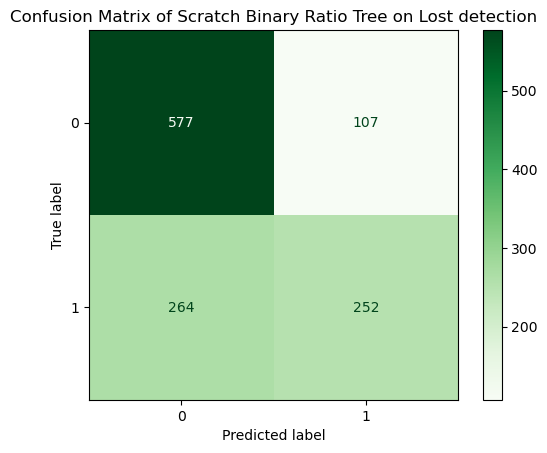

In [317]:
_ = evaluate_model(y_test_lost, y_pred_lost_scratch_binary, "Scratch Binary Decision Tree on Lost detection", "Blues")
_ = evaluate_model(y_test_lost, y_pred_lost_scratch_ratio, "Scratch Binary Ratio Tree on Lost detection", "Greens")

<div style="
  background: linear-gradient(135deg, #e8b7e8, #ffb6f4);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #481344;
  color: #2b0a2a;
">

  <h1 style="color: #2b0a2a;">⚡ Part B: Fast Spam Filtering with Scikit-learn</h1>

  <p style="font-size: 17px; line-height: 1.7; color: #2b0a2a;">
    Now you can use ready-made tools from Scikit-learn.
    In this part, focus only on predicting <code>is_spam</code>.
  </p>

</div>

### Train a Naive Bayes spam filter

Model: Naive Bayes on Spam detection
Accuracy:	0.7008
----------------------------------------
Precision:	0.8369
----------------------------------------
Recall:		0.3779
----------------------------------------
F1 Score:	0.5207


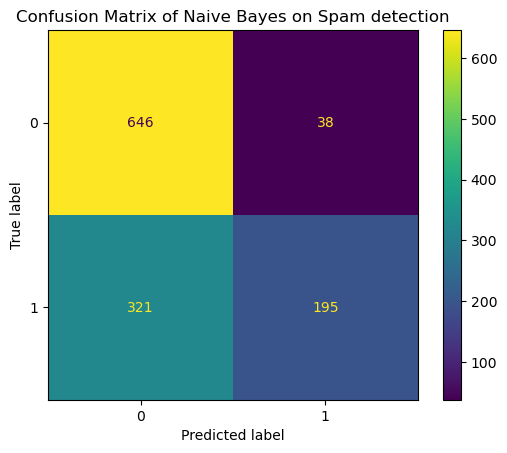

In [318]:
from sklearn.naive_bayes import GaussianNB 
# Create a GaussianNB model
naive_bayes_spam = GaussianNB()
# Train the model using X_train_spam and y_train_spam
naive_bayes_spam.fit(X_train_spam, y_train_spam)
# Predict on X_val_spam
y_pred_bayes_spam = naive_bayes_spam.predict(X_test_spam)
# Evaluate the model using Accuracy and F1-score
bayes_spam_res = evaluate_model(y_test_spam, y_pred_bayes_spam, "Naive Bayes on Spam detection")

### Random Forest and GridSearchCV

Best parameters: {'max_depth': 5}
----------------------------------------
Best CV F1 Score: 0.5307
Model: Random Forest on Spam detection
Accuracy:	0.6983
----------------------------------------
Precision:	0.7674
----------------------------------------
Recall:		0.4283
----------------------------------------
F1 Score:	0.5498


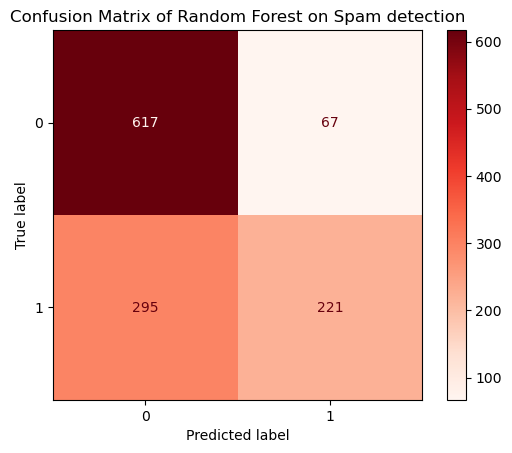

In [319]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
# Create a RandomForestClassifier
random_forest_spam = RandomForestClassifier()
# Create a param_grid for different max_depth values
param_grid = {
    "max_depth": [3, 5, 7, 10, 12, 15, 20, None]
}
# Use GridSearchCV with scoring="f1"
grid_search = GridSearchCV(
    random_forest_spam,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
# Fit GridSearchCV on the training data
grid_search.fit(X_train_spam, y_train_spam)
# Print the best parameters
print(f"Best parameters: {grid_search.best_params_}", end=END)
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
# Predict using the best model
y_pred_forest_spam = grid_search.best_estimator_.predict(X_test_spam)
# Evaluate the Random Forest model
forest_spam_res = evaluate_model(y_test_spam, y_pred_forest_spam, "Random Forest on Spam detection", "Reds")

### Final model comparison

In [324]:
comparison_df = pd.DataFrame([scratch_binary_spam_res, scratch_ratio_spam_res, bayes_spam_res, forest_spam_res])

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Scratch Binary Decision Tree on Spam detection,0.6933,0.7891,0.3915,0.5233
1,Scratch Binary Ratio Tree on Spam detection,0.6950,0.6984,0.5116,0.5906
2,Naive Bayes on Spam detection,0.7008,0.8369,0.3779,0.5207
3,Random Forest on Spam detection,0.6983,0.7674,0.4283,0.5498


<div style="
  background: linear-gradient(135deg, #9668b1, #8fb5d7, #78b9f6);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🧠 Mental Wellness AI Guardian 🌿
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a Simple Neural Network from Scratch
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, wellness data scientist!  
    In this mission, you will train a small neural network to understand student habits
    and classify mental state patterns.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    💤 Sleep • 📰 News • 📱 Screen Time • 🔐 VPN Attempts • 🤖 Neural Network
  </div>

</div>

### Imports

In [325]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Logistic regression from scratch

In [372]:
class SoftmaxRegressionScratch:
    """
    Multiclass logistic regression using softmax and gradient descent.
    """
    def __init__(self, learning_rate=0.01, n_iterations=5000):
        """
        Initialize the model.
        Args:
            learning_rate (float): step size for gradient descent.
            n_iterations (int): number of training epochs.
        """
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None   # shape (n_features, n_classes)
        self.bias = None      # shape (n_classes,)
        self.loss_history = []
        self.classes = None

    def _softmax(self, z):
        """
        Compute softmax probabilities for each sample.
        Args:
            z (np.ndarray): linear output, shape (n_samples, n_classes)
        Returns:
            np.ndarray: probabilities, shape (n_samples, n_classes)
        """
        z_stable = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, n_classes):
        """
        Convert integer labels to one-hot encoding.
        Args:
            y (np.ndarray): labels, shape (n_samples,)
            n_classes (int): number of unique classes
        Returns:
            np.ndarray: one-hot matrix, shape (n_samples, n_classes)
        """
        n_samples = len(y)
        one_hot_encode = np.zeros((n_samples, n_classes))
        y_mapped = np.array([np.where(self.classes == label)[0][0] for label in y])
        one_hot_encode[np.arange(n_samples), y_mapped] = 1
        return one_hot_encode

    def fit(self, X : pd.DataFrame, y):
        """
        Train the model using gradient descent.
        Args:
            X (np.ndarray): training features, shape (n_samples, n_features)
            y (np.ndarray): training labels, shape (n_samples,)
        """
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        
        # Initialize parameters
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)

        # One-hot encode labels
        y_one_hot_encode = self._one_hot(y, n_classes)
        
        # Gradient descent loop
        for i in range(self.n_iter):
            # Forward pass: compute linear output z, then probabilities
            z = np.dot(X, self.weights) + self.bias
            probs = self._softmax(z)

            # Compute cross-entropy loss (store in self.loss_history if desired)
            epsilon = 1e-12
            loss = -np.mean(np.sum(y_one_hot_encode * np.log(probs + epsilon), axis=1))
            self.loss_history.append(loss)
            
            # Compute gradients
            delta = (probs - y_one_hot_encode) / n_samples
            dw = np.dot(X.T, delta)
            db = np.sum(delta, axis=0)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # print loss every 1000 iterations
            if i % 1000 == 0:
                print(f"Iter {i}: loss = {loss:.4f}")

    def predict_proba(self, X):
        """
        Predict class probabilities for new data.
        Args:
            X (np.ndarray): features, shape (n_samples, n_features)
        Returns:
            np.ndarray: probabilities, shape (n_samples, n_classes)
        """
        # compute linear output and apply softmax
        z = np.dot(X, self.weights) + self.bias
        return self._softmax(z)

    def predict(self, X):
        """
        Predict class labels for new data.
        Args:
            X (np.ndarray): features, shape (n_samples, n_features)
        Returns:
            np.ndarray: predicted labels, shape (n_samples,)
        """
        # get probabilities and return argmax
        probs = self.predict_proba(X)
        class_indices = np.argmax(probs, axis=1)
        return self.classes[class_indices]


### Load data

In [373]:
df_burnout = pd.read_csv(f"{DATA_DIR}student_burnout.csv")
print(f"Shape: {df_burnout.shape}")
print(f"Class Distributaion:")
print(df_burnout["mental_state"].value_counts().sort_index())
df_burnout.head()

Shape: (1000, 6)
Class Distributaion:
mental_state
0    494
1    436
2     70
Name: count, dtype: int64


,sleep_hours_avg,news_read_count,vpn_connection_attempts,pending_hw,screen_time_hours,mental_state
0,5.9,5,3,2,9.7,1
1,8.8,4,9,0,12.6,0
2,7.7,2,3,1,6.8,0
3,7.0,5,8,2,2.8,1
4,4.8,8,5,0,8.2,1


### Preprocessing

In [384]:
# Separate features (X) and target (y = mental_state)
X_burn = df_burnout.drop(columns=["mental_state"])
y_burn = df_burnout["mental_state"]

# Split into train (80%) and validation (20%) with stratification
X_train_burn, X_test_burn, y_train_burn, y_test_burn = train_test_split(
    X_burn, y_burn, test_size=0.2, stratify=y_burn
)

# Scale features using StandardScaler
scaler_burn = StandardScaler()
X_train_burn_scaled = scaler_burn.fit_transform(X_train_burn)
X_test_burn_scaled = scaler_burn.transform(X_test_burn)

print(f"Train: {X_train_burn_scaled.shape} | Val: {X_test_burn_scaled.shape}")
print("Class counts in train:", np.bincount(y_train_burn))

Train: (800, 5) | Val: (200, 5)
Class counts in train: [395 349  56]


### Train and evaluate custom model

Iter 0: loss = 1.0986
Iter 1000: loss = 0.5278
Iter 2000: loss = 0.4707
Iter 3000: loss = 0.4431
Iter 4000: loss = 0.4266
Scratch Softmax Training time: 0.5728
	Scratch Softmax Regression:
Accuracy:	0.8350
----------------------------------------
F1 Score:	0.7858
----------------------------------------
Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.90      0.84      0.87        99
     Tired (1)       0.78      0.87      0.82        87
Burned out (2)       0.80      0.57      0.67        14

      accuracy                           0.83       200
     macro avg       0.83      0.76      0.79       200
  weighted avg       0.84      0.83      0.83       200



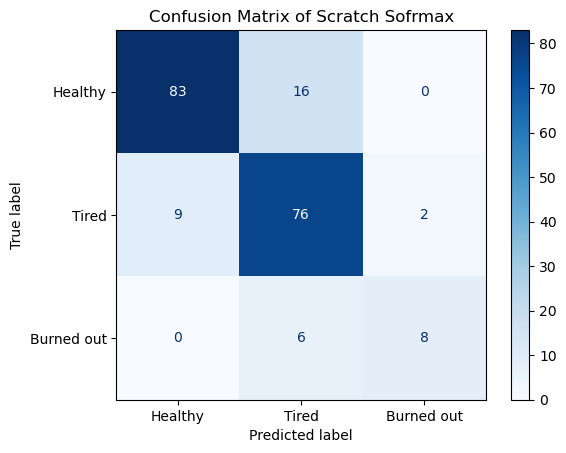

In [385]:
softmax_scratch_burn = SoftmaxRegressionScratch()

# Measure training time and call fit()
t0 = time.time()
softmax_scratch_burn.fit(X_train_burn_scaled, y_train_burn)
scratch_softmax_train_time = time.time() - t0
print(f"Scratch Softmax Training time: {scratch_softmax_train_time:.4f}")

# Predict on validation set and compute accuracy, classification report,
#       and confusion matrix
y_pred_scratch_softmax = softmax_scratch_burn.predict(X_test_burn_scaled)

scratch_softmax_accuracy = accuracy_score(y_test_burn, y_pred_scratch_softmax)
scratch_softmax_f1 = f1_score(y_test_burn, y_pred_scratch_softmax, average="macro", zero_division=0)

print("=" * 40)
print("\tScratch Softmax Regression:")
print("=" * 40)
print(f"Accuracy:\t{scratch_softmax_accuracy:.4f}", end=END)
print(f"F1 Score:\t{scratch_softmax_f1:.4f}", end=END)
print("Classification Report:")
print(classification_report(y_test_burn, y_pred_scratch_softmax, target_names=["Healthy (0)", "Tired (1)", "Burned out (2)"]))

softmax_cm_scratch = confusion_matrix(y_test_burn, y_pred_scratch_softmax)
disp = ConfusionMatrixDisplay(confusion_matrix=softmax_cm_scratch, display_labels=["Healthy", "Tired", "Burned out"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix of Scratch Sofrmax")
plt.show()

### Compare with sklearn's LogisticRegression

	Training Time Comparison
Scratch Softmax:		0.5728
----------------------------------------
Sklearn Logistic Regression:	0.0251

Accuracy Comparison
Scratch Softmax:		0.8350
----------------------------------------
Sklearn Logistic Regression:	0.8300

Macro F1 Comparison
Scratch Softmax:		0.7858
----------------------------------------
Sklearn Logistic Regression:	0.7967

Sklearn Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.89      0.84      0.86        99
     Tired (1)       0.78      0.84      0.81        87
Burned-out (2)       0.71      0.71      0.71        14

      accuracy                           0.83       200
     macro avg       0.80      0.80      0.80       200
  weighted avg       0.83      0.83      0.83       200



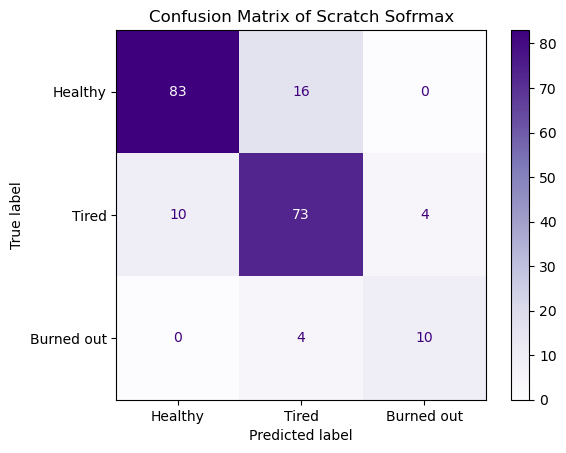

In [409]:
# Train sklearn's LogisticRegression (multinomial, lbfgs)
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=5000)

t0 = time.time()
logistic_regression.fit(X_train_burn_scaled, y_train_burn)
sklearn_logistic_train_time = time.time() - t0

# Compare training time and performance metrics
y_pred_sklearn_softmax = logistic_regression.predict(X_test_burn_scaled)
sklearn_softmax_accuracy = accuracy_score(y_test_burn, y_pred_sklearn_softmax)
sklearn_softmax_f1 = f1_score(y_test_burn, y_pred_sklearn_softmax, average="macro", zero_division=0)

print("=" * 40)
print("\tTraining Time Comparison")
print("=" * 40)
print(f"Scratch Softmax:\t\t{scratch_softmax_train_time:.4f}", end=END)
print(f"Sklearn Logistic Regression:\t{sklearn_logistic_train_time:.4f}")
print("=" * 40)
print()
print("=" * 40)
print("Accuracy Comparison")
print("=" * 40)
print(f"Scratch Softmax:\t\t{scratch_softmax_accuracy:.4f}", end=END)
print(f"Sklearn Logistic Regression:\t{sklearn_softmax_accuracy:.4f}")
print("=" * 40)
print()
print("=" * 40)
print("Macro F1 Comparison")
print("=" * 40)
print(f"Scratch Softmax:\t\t{scratch_softmax_f1:.4f}", end=END)
print(f"Sklearn Logistic Regression:\t{sklearn_softmax_f1:.4f}")
print("=" * 40)
print()
print("=" * 40)
print("Sklearn Classification Report:")
print("=" * 40)
print(classification_report(y_test_burn, y_pred_sklearn_softmax,
                             target_names=["Healthy (0)", "Tired (1)", "Burned-out (2)"]))

softmax_cm_sklearn = confusion_matrix(y_test_burn, y_pred_sklearn_softmax)
disp = ConfusionMatrixDisplay(confusion_matrix=softmax_cm_sklearn, display_labels=["Healthy", "Tired", "Burned out"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix of Scratch Sofrmax")
plt.show()

### Imbalanced Data Analysis

In [408]:
# Print class distribution in training set
unique, counts = np.unique(y_train_burn, return_counts=True)
print("=" * 40)
print("Class distribution in training set:")
print("=" * 40)
for cls, cnt in zip(unique, counts):
    names = {0: "Healthy", 1: "Tired", 2: "Burned-out"}
    print(f"Class {cls} ({names[cls]}): {cnt} samples ({cnt/len(y_train_burn)*100:.1f}%)")
print("=" * 40)
# Explain why accuracy alone is misleading
# Show macro/weighted F1 scores
f1_macro_scratch = f1_score(y_test_burn, y_pred_scratch_softmax, average="macro")
f1_weighted_scratch = f1_score(y_test_burn, y_pred_scratch_softmax, average="weighted")

print()
print("=" * 40)
print("Custom Softmax Regression:")
print("=" * 40)
print(f"Accuracy:\t\t{scratch_softmax_accuracy:.4f}")
print(f"Macro F1-Score:\t\t{f1_macro_scratch:.4f}  (treats all classes equally)")
print(f"Weighted F1-Score:\t{f1_weighted_scratch:.4f}  (weights by class size)")
print("=" * 40)
print()

# Print weight matrix for analytical question
print("=" * 40)
print("Weight Matrix W (shape: n_features x n_classes)")
print("=" * 40)
feature_names = df_burnout.drop(columns=['mental_state']).columns.tolist()
for i, feature in enumerate(feature_names):
    print(f"{feature:30}:{softmax_scratch_burn.weights[i]}")
print("=" * 40)

Class distribution in training set:
Class 0 (Healthy): 395 samples (49.4%)
Class 1 (Tired): 349 samples (43.6%)
Class 2 (Burned-out): 56 samples (7.0%)

Custom Softmax Regression:
Accuracy:		0.8350
Macro F1-Score:		0.7858  (treats all classes equally)
Weighted F1-Score:	0.8343  (weights by class size)

Weight Matrix W (shape: n_features x n_classes)
sleep_hours_avg               :[ 1.51420214 -0.43347469 -1.08072745]
news_read_count               :[-1.04985915  0.22059559  0.82926356]
vpn_connection_attempts       :[-0.81875753  0.12695904  0.69179849]
pending_hw                    :[-1.02948398  0.18545027  0.84403371]
screen_time_hours             :[-1.00916873  0.24989303  0.7592757 ]


<div style="
  background: linear-gradient(135deg, #7dbcf3, #9ff98d, #d6a870);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 20px rgba(0,0,0,0.15);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🏔️ Payamnouria Mountain AI Mission 🤖
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Predict Safe and Dangerous Trekking Routes
  </h2>

  <p style="font-size: 18px;">
    Welcome, young data explorer! Today you will help hikers choose safer mountain paths.
  </p>

</div>

### Imports

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

### Load the dataset

In [410]:
CSV_PATH = "trekking_expedition.csv"

# Read the CSV file into a DataFrame named df
df_trek = pd.read_csv(f"{DATA_DIR}{CSV_PATH}")
# Print the shape of the dataset
print(f"Shape: {df_trek.shape}")
# Display the first 5 rows
df_trek.head()

Shape: (6000, 5)


,slope_angle,wolf_prob,rain_mm,cold_resistance,is_safe
0,31.82,0.295,69.44,Medium,0
1,38.55,0.170,5.29,Low,1
2,7.46,0.397,50.34,High,1
3,50.96,0.536,60.98,Low,0
4,39.38,0.217,28.89,High,1


### Basic cleaning

In [414]:
required_columns = [
    "slope_angle",
    "wolf_prob",
    "rain_mm",
    "cold_resistance",
    "is_safe"
]

# Check that all required columns exist in df
missing_cols = [c for c in required_columns if c not in df_trek.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")
print("All required columns present")

# Remove duplicate rows
df_trek = df_trek.drop_duplicates()

# Convert these columns to numeric:
#       slope_angle, wolf_prob, rain_mm, is_safe
for col in ["slope_angle", "wolf_prob", "rain_mm", "is_safe"]:
    df_trek[col] = pd.to_numeric(df_trek[col], errors="coerce")

# Remove rows with missing values
df_trek = df_trek.dropna()

# Keep only rows where:
#       slope_angle > 0
#       0 <= wolf_prob <= 1
#       rain_mm >= 0
#       is_safe is either 0 or 1
df_trek = df_trek[df_trek["slope_angle"] > 0]
df_trek = df_trek[(0 <= df_trek["wolf_prob"]) & (df_trek["wolf_prob"] <= 1)]
df_trek = df_trek[df_trek["rain_mm"] >= 0]
df_trek = df_trek[df_trek["is_safe"].isin([0, 1])]

# Keep only valid cold_resistance values:
#       Low, Medium, High
df_trek = df_trek[df_trek["cold_resistance"].isin(["Low", "Medium", "High"])]

# Convert is_safe to integer
df_trek["is_safe"] = df_trek["is_safe"].astype(int)

# Print the new shape of the cleaned dataset
print(f"Cleaned shape: {df_trek.shape}")
# Print the target distribution
print("=" * 40)
print("Target distribution:")
print(df_trek["is_safe"].value_counts())

All required columns present
Cleaned shape: (6000, 5)
Target distribution:
is_safe
1    3912
0    2088
Name: count, dtype: int64


### Create environmental_danger

In [ ]:
def add_environmental_danger(data : pd.DataFrame):
    data = data.copy()

    # Create a new column named environmental_danger
    # Formula:
    # environmental_danger = slope_angle * rain_mm * (1 + wolf_prob)
    data["environmental_danger"] = (
        data["slope_angle"] * data["rain_mm"] * (1 + data["wolf_prob"])
    )
    return data

### Preprocess Train and Validation

In [417]:
def preprocess_train_validation(X_train : pd.DataFrame, X_val : pd.DataFrame):
    X_train = X_train.copy()
    X_val = X_val.copy()

    categorical_columns = ["cold_resistance"]

    numeric_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

    # -----------------------------------------------------
    # OneHotEncoder for cold_resistance
    # -----------------------------------------------------

    # Create OneHotEncoder with:
    #       handle_unknown="ignore"
    #       sparse_output=False
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    # Fit encoder only on X_train[categorical_columns]
    one_hot_encoder.fit(X_train[categorical_columns])
    # Transform both X_train and X_val categorical columns
    train_one_hot_encoder_arr = one_hot_encoder.transform(X_train[categorical_columns])
    val_one_hot_encoder_arr = one_hot_encoder.transform(X_val[categorical_columns])
    # Convert encoded arrays to DataFrames
    #       Use encoder.get_feature_names_out(categorical_columns)
    cat_feature_names = one_hot_encoder.get_feature_names_out(categorical_columns)
    train_cat_df = pd.DataFrame(train_one_hot_encoder_arr, columns=cat_feature_names, index=X_train.index)
    val_cat_df = pd.DataFrame(val_one_hot_encoder_arr, columns=cat_feature_names, index=X_val.index)
    
    # -----------------------------------------------------
    # StandardScaler for numerical columns
    # -----------------------------------------------------

    # Create a StandardScaler
    scaler = StandardScaler()
    # Fit scaler only on X_train[numeric_columns]
    scaler.fit(X_train[numeric_columns])
    # Transform both X_train and X_val numeric columns
    train_num_arr = scaler.transform(X_train[numeric_columns])
    val_num_arr = scaler.transform(X_val[numeric_columns])
    # Convert scaled arrays to DataFrames
    train_num_df = pd.DataFrame(train_num_arr, columns=numeric_columns, index=X_train.index)
    val_num_df = pd.DataFrame(val_num_arr, columns=numeric_columns, index=X_val.index)
    # -----------------------------------------------------
    # Combine numeric and categorical features
    # -----------------------------------------------------

    # Concatenate processed numeric and categorical DataFrames
    #       for both Train and Validation
    X_train_processed = pd.concat([train_num_df, train_cat_df], axis=1)
    X_val_processed = pd.concat([val_num_df, val_cat_df], axis=1)

    return X_train_processed, X_val_processed


### Train and evaluate model

In [ ]:
def train_and_evaluate(data : pd.DataFrame, experiment_name):
    print("\n" + "=" * 70)
    print(experiment_name)
    print("=" * 70)

    # Set X by dropping "is_safe"
    X = data.drop(columns=["is_safe"])
    # Set y as data["is_safe"]
    y = data["is_safe"]
    # Split X and y into Train and Validation
    #       Use test_size=0.2, random_state=42, stratify=y
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    # Preprocess Train and Validation using preprocess_train_validation
    X_train_proc, X_val_proc = preprocess_train_validation(X_train, X_val)

    # Create DecisionTreeClassifier
    #       Suggested parameters:
    #       max_depth=4
    #       min_samples_split=25
    #       min_samples_leaf=12
    #       random_state=42
    decision_tree = DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=25,
        min_samples_leaf=12,
        random_state=42
    )
    # Fit the model on processed Train data
    decision_tree.fit(X_train_proc, y_train)
    # Predict on processed Validation data
    y_pred = decision_tree.predict(X_val_proc)
    # Calculate Accuracy and F1-score
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    # Print Accuracy and F1-score
    print(f"Accuracy:\t{accuracy}", end=END)
    print(f"F1 Score:\t{f1}")
    # Return a dictionary with:
    #       experiment, accuracy, f1_score
    return {"experiment": experiment_name, "accuracy": round(accuracy, 4), "f1_score": round(f1, 4)}, decision_tree, X_train_proc

### Run experiments

In [ ]:
# Create df_baseline as a copy of df
df_baseline = df_trek.copy()
# Train and evaluate the baseline model
#       Experiment name:
#       "Baseline Decision Tree - Without environmental_danger"
result_baseline, clf_baseline, _ = train_and_evaluate(
    df_baseline, "Baseline Decision Tree - Without environmental_danger"
)
# Create df_engineered by calling add_environmental_danger(df)

# Train and evaluate the engineered model
#       Experiment name:
#       "Decision Tree - With environmental_danger"


### Final comparison

In [308]:
# Create a DataFrame from the two result dictionaries

# Print the comparison table rounded to 4 decimals

# Print the change in Accuracy

# Print the change in F1-score

<div style="
  background: linear-gradient(135deg, #f197a7, #efb66f, #f9fc95);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #3a2c2c;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🎵 Smofy Koohestan AI Party 🎸
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a KNN Music Genre Recommender
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, music data explorer!  
    In this mission, you will help students find their favorite music style using age,
    daily listening time, favorite instruments, and personality traits.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    🎧 Student Data • 📏 Distance Calculation • 👥 K-Nearest Neighbors • 🎶 Genre Prediction
  </div>

</div>

### Imports

In [309]:
## TODO:

### Data Preparation

In [310]:
# Load csv
# df = ...

# Separate features (X) and target (y = music_genre)

# Identify categorical columns and numeric columns 

# Apply one-hot encoding to categorical columns (use OneHotEncoder)
# Combine encoded categorical with numeric columns

# Split into train (80%) and validation (20%) with stratification

# Scale all features using StandardScaler (fit on train, transform both)


### Train and evaluate custom KNN (with k=5)

In [311]:
# Create KNeighborsClassifier model with k=5

# Fit the model on scaled training data

# Predict on validation data

# Compute accuracy and macro F1-score

# Print classification report



### Effect of k on bias/variance (plot)

In [312]:
k_values = [1, 3, 5, 7, 11, 21, 51]
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(k=k)
    knn.fit(X_train_scaled, y_train)
    
    # Train accuracy (predict on training set)
    y_train_pred = knn.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    # Validation accuracy
    y_val_pred = knn.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)
    
    print(f"k={k:2d} -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


NameError: name 'KNeighborsClassifier' is not defined

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(k_values, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Model Performance (KNN)')
plt.legend()
plt.grid(True)
plt.show()
